In [49]:
from src.data_loader import download_prices

from src.returns import (
    calculate_simple_returns,
    calculate_log_returns,
    validate_returns
)

from src.portfolio import (
    calculate_portfolio_returns,
    calculate_portfolio_pnl
)

from src.risk_metrics import (
    calculate_portfolio_statistics
)

from src.var import (
    historical_var
)

from src.expected_shortfall import (
    historical_expected_shortfall
)

In [50]:
tickers = [
    "RELIANCE.NS",
    "ESCORTS.NS",
    "INFY.NS",
    "ABB.NS",
    "HDFCBANK.NS"
]

#weightage of stocks in portfolio
weights = [
    0.20,   # RELIANCE
    0.20,   # ESCORTS
    0.20,   # INFY
    0.20,   # ABB
    0.20    # HDFCBANK
]

#assigning portfolio value in Rs
portfolio_value = 10_000_000

In [51]:
prices = download_prices(
    tickers,
    "2022-04-01",
    "2026-03-31"
)

prices = prices.round(2)

print(prices.head())

[*********************100%***********************]  5 of 5 completed

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [52]:
returns = calculate_simple_returns(prices)

print(returns.head())

Ticker        ABB.NS  ESCORTS.NS  HDFCBANK.NS   INFY.NS  RELIANCE.NS
Date                                                                
2022-04-04  0.007688    0.039518     0.100119 -0.010821     0.002960
2022-04-05  0.036141    0.056230    -0.029295 -0.011605    -0.014132
2022-04-06  0.000862    0.013464    -0.035694 -0.017330    -0.002674
2022-04-07 -0.007830   -0.092170    -0.021981 -0.009757    -0.017636
2022-04-08  0.021348   -0.061246    -0.001395  0.001986     0.016631


In [53]:
print(validate_returns(returns))

{'rows': 986, 'columns': 5, 'missing_values': np.int64(0), 'infinite_values': np.int64(0)}


In [54]:
portfolio_returns = calculate_portfolio_returns(
    returns,
    weights
)

print(prices.head().round(2))

Ticker       ABB.NS  ESCORTS.NS  HDFCBANK.NS  INFY.NS  RELIANCE.NS
Date                                                              
2022-04-01  2043.44     1635.69       704.66  1672.63      1202.88
2022-04-04  2059.15     1700.33       775.21  1654.53      1206.44
2022-04-05  2133.57     1795.94       752.50  1635.33      1189.39
2022-04-06  2135.41     1820.12       725.64  1606.99      1186.21
2022-04-07  2118.69     1652.36       709.69  1591.31      1165.29


In [55]:
#calculating daily PnL
portfolio_pnl = calculate_portfolio_pnl(
    portfolio_returns,
    portfolio_value
)

print(portfolio_pnl.head(10))

Date
2022-04-04    278927.991277
2022-04-05     74678.213350
2022-04-06    -82743.442739
2022-04-07   -298747.188883
2022-04-08    -45351.545925
2022-04-11   -110984.815443
2022-04-12   -156029.769147
2022-04-13    -16178.120083
2022-04-18   -279794.518727
2022-04-19   -104888.559183
Name: Portfolio P&L, dtype: float64


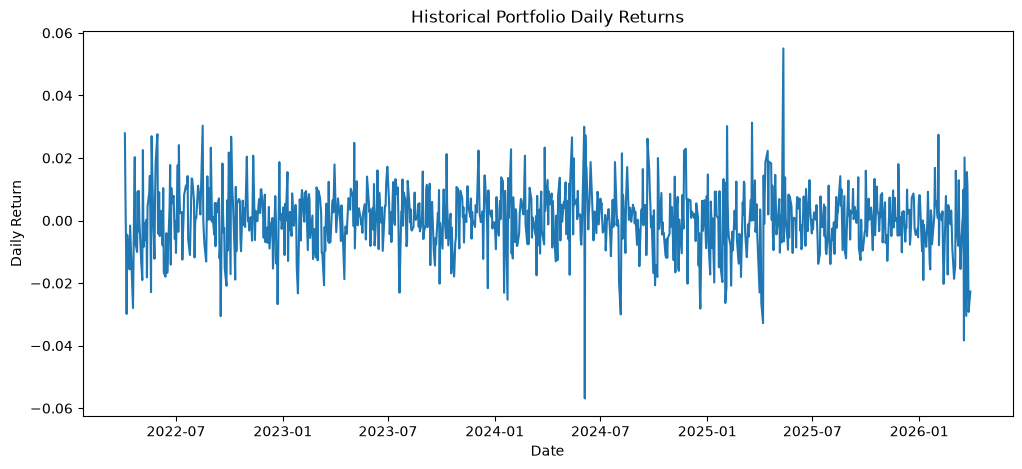

In [56]:
#Plotting Portfolio returns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    portfolio_returns.index,
    portfolio_returns
)

plt.title("Historical Portfolio Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return")

plt.show()

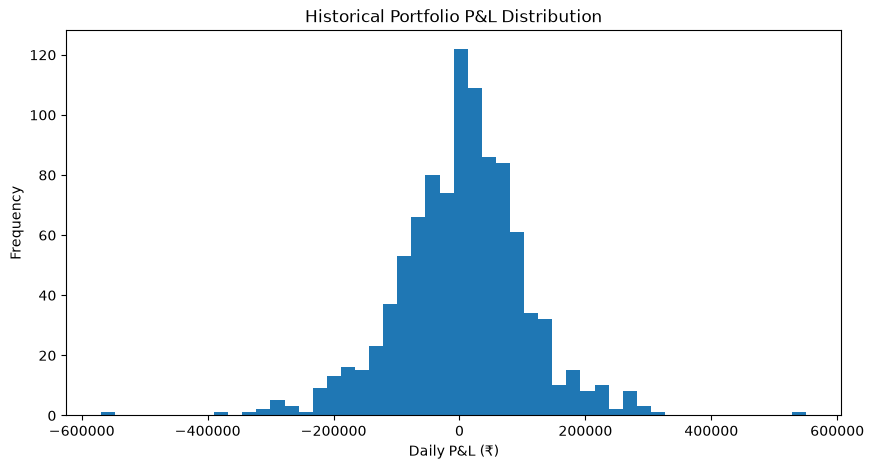

In [57]:
#Plotting PnL Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    portfolio_pnl,
    bins=50
)

plt.title("Historical Portfolio P&L Distribution")
plt.xlabel("Daily P&L (₹)")
plt.ylabel("Frequency")

plt.show()

In [58]:
#portfolio statistics

statistics = calculate_portfolio_statistics(
    portfolio_returns
)

for key, value in statistics.items():
    print(f"{key}: {value:.6f}")

mean_return: 0.000418
volatility: 0.010154
minimum_return: -0.056875
maximum_return: 0.055030
skewness: -0.160660
kurtosis: 2.364920


In [59]:
#Calculate Historical VaR
# 1-day 95% VaR 
var_95 = historical_var(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.95
)

# 1-day 99% VaR 
var_99 = historical_var(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.99
)

print(f"95% 1-Day VaR: ₹{var_95:,.2f}")
print(f"99% 1-Day VaR: ₹{var_99:,.2f}")

95% 1-Day VaR: ₹167,646.97
99% 1-Day VaR: ₹269,177.63


In [60]:
# Expected Shortfall at 95% CI
es_95 = historical_expected_shortfall(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.95
)

# Expected Shortfall at 99% CI
es_99 = historical_expected_shortfall(
    portfolio_returns,
    portfolio_value,
    confidence_level=0.99
)

print(f"95% Expected Shortfall: ₹{es_95:,.2f}")
print(f"99% Expected Shortfall: ₹{es_99:,.2f}")

95% Expected Shortfall: ₹229,691.77
99% Expected Shortfall: ₹334,273.41


In [61]:
#Market Risk Summary
print("=" * 50)
print("           MARKET RISK SUMMARY")
print("=" * 50)

print(f"\nPortfolio Value: ₹{portfolio_value:,.2f} Rs")

print("\n--- Portfolio Statistics ---")

print(
    f"Mean Daily Return: "
    f"{statistics['mean_return'] * 100:.4f}%"
)

print(
    f"Daily Volatility: "
    f"{statistics['volatility'] * 100:.4f}%"
)

print(
    f"Worst Daily Return: "
    f"{statistics['minimum_return'] * 100:.4f}%"
)

print(
    f"Best Daily Return: "
    f"{statistics['maximum_return'] * 100:.4f}%"
)

print("\n--- Value at Risk ---")

print(
    f"95% Historical VaR: "
    f"₹{var_95:,.2f}"
)

print(
    f"99% Historical VaR: "
    f"₹{var_99:,.2f}"
)

print("\n--- Expected Shortfall ---")

print(
    f"95% Expected Shortfall: "
    f"₹{es_95:,.2f}"
)

print(
    f"99% Expected Shortfall: "
    f"₹{es_99:,.2f}"
)

print("\n" + "=" * 50)

           MARKET RISK SUMMARY

Portfolio Value: ₹10,000,000.00 Rs

--- Portfolio Statistics ---
Mean Daily Return: 0.0418%
Daily Volatility: 1.0154%
Worst Daily Return: -5.6875%
Best Daily Return: 5.5030%

--- Value at Risk ---
95% Historical VaR: ₹167,646.97
99% Historical VaR: ₹269,177.63

--- Expected Shortfall ---
95% Expected Shortfall: ₹229,691.77
99% Expected Shortfall: ₹334,273.41

